# Проект "Простые вещи"

**Цель проекта:**
создание аналитической панели для заказчика:
- общая информация 
- анализ платежей 
- анализ поведения пользователей 
- RFM-анализ 
- когортный анализ

**Задачи проекта:**
Предполагается, что в ходе работы над проектом будут решены следующие задачи:
- обработанны исходные данные: файлы объединены в один
- проведена предобработка данных 
- проведён eda 
- найдены инсайты 
- создана аналитическая панель (любая BI, или Юпитер, collab) 
- любые другие виды анализа, визуализации и по желанию студента

 

## 📌 Оглавление  
1. [Ознакомление с данными и предобработка](#Ознакомление-с-данными-и-предобработка)  
   - [Анализ столбцов](#Анализ-столбцов)  
   - [Создание DataFrame: завершенные и отклоненные операции](#Создание-DataFrame-завершенные-и-отклоненные-операции)  
2. [Исследовательский анализ данных (EDA)](#Исследовательский-анализ-данных)  
3. [Анализ платежей](#Анализ-платежей)
   - [Основные метрики по платежам](#Основные-метрики-по-платежам)
   - [Распределение сумм платежей (гистограмма)](#Распределение-сумм-платежей-гистограмма)
   - [Динамика платежей по месяцам](#Динамика-платежей-по-месяцам)
   - [ARPU (Средний доход на пользователя), Churn Rate (Отток пользователей), LTV (Lifetime Value)](#ARPU-Churn-Rate-LTV)
4. [Анализ поведения пользователей](#Анализ-поведения-пользователей)
   - [Количество уникальных пользователей и их активность](#Количество-уникальных-пользователей-и-их-активность)
   - [Средний интервал между платежами](#Средний-интервал-между-платежами)
   - [Динамика новых и возвращающихся пользователей](#Динамика-новых-и-возвращающихся-пользователей)
5. [RFM-анализ](#RFM-анализ)  
6. [Когортный анализ](#Когортный-анализ)  

---


## 1. Ознакомление с данными и предобработка <a id="Ознакомление-с-данными-и-предобработка"></a> 

In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
from datetime import datetime

!pip install sweetviz
import sweetviz as sv

!pip install ydata-profiling
from ydata_profiling import ProfileReport 

!pip install jupytext


In [2]:
# Ссылки на Google Sheets
file_links = {
    "январь": "https://docs.google.com/spreadsheets/d/1ofRkizmDZKWk3wxTMCb7NCMHpnT0wPEF/export?format=xlsx",
    "февраль": "https://docs.google.com/spreadsheets/d/11h0CMZMNVSGtMEV5t3gMbKs4RMKJHIP7/export?format=xlsx",
    "март": "https://docs.google.com/spreadsheets/d/1VJAXfTccrUwQx4WpAkMtV3uIRwfBMJBH/export?format=xlsx",
    "апрель": "https://docs.google.com/spreadsheets/d/1IBe3JFldzHmpiHGrRnNfZTt2KAMtFIPq/export?format=xlsx",
    "май": "https://docs.google.com/spreadsheets/d/1FrXwbi-X0a7PJgBY-wzpLniyPpV0IML8/export?format=xlsx",
    "июнь": "https://docs.google.com/spreadsheets/d/19I2HrXK1TVuwaQDnLIpMC2mz68lXTwbz/export?format=xlsx",
    "июль": "https://docs.google.com/spreadsheets/d/1wKDWDRWUnJUnvzo2QtO5wMP0Z-P6h7V4/export?format=xlsx"
}

# Список для хранения загруженных данных
dataframes = []

# Загрузка данных
for name, url in file_links.items():
    try:
        df = pd.read_excel(url, dtype={"Номер": str, "ID плательщика": str, "Сайт": str})
        df["source_file"] = name  # Добавляем колонку с именем файла
        df["Дата и время"] = pd.to_datetime(df["Дата и время"], errors="coerce")  # Форматирование даты
        dataframes.append(df)
        print(f"Файл {name} загружен, размер: {df.shape}")
    except Exception as e:
        print(f"Ошибка при загрузке {name}: {e}")

# Объединение всех данных в один DataFrame
data = pd.concat(dataframes, ignore_index=True)

display(data)


Файл январь загружен, размер: (335, 17)
Файл февраль загружен, размер: (338, 17)
Файл март загружен, размер: (401, 27)
Файл апрель загружен, размер: (394, 29)
Файл май загружен, размер: (688, 32)
Файл июнь загружен, размер: (1163, 24)
Файл июль загружен, размер: (829, 43)


,Номер,Дата и время,Банк,Сайт,# заказа,ID плательщика,Тип,Сумма операции,Валюта,Сумма комиссии,...,Страна,Город,Отчество,Фамилия,Ник,Телефон,Дата рождения,Адрес.1,Комментарий,Case ID
0,2080468405,2024-01-31 20:18:00,Тинькофф,prostieveschi.ru,NaN,12ost****@mail.ru,Регулярная оплата,1000,RUB,32.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2080039460,2024-01-30 22:18:00,Тинькофф,prostieveschi.ru,NaN,tigro****@gmail.com,Регулярная оплата,200,RUB,6.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2079851261,2024-01-30 14:55:00,Тинькофф,prostieveschi.ru,NaN,nat****@gmail.com,Регулярная оплата,300,RUB,9.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2079846986,2024-01-30 14:45:00,Тинькофф,prostieveschi.ru,NaN,natalk****@inbox.ru,Регулярная оплата,700,RUB,22.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2079829457,2024-01-30 14:09:00,Тинькофф,prostieveschi.ru,NaN,in****@yandex.ru,Регулярная оплата,500,RUB,16.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4143,2122152187,NaT,Тинькофф,prostieveschi.ru,NaN,NaN,Регулярная оплата,500,NaN,0.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4144,2122141347,2024-07-01 09:55:00,Тинькофф,prostieveschi.ru,NaN,NaN,Регулярная оплата,100,NaN,3.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4145,2122130490,2024-07-01 08:32:00,Тинькофф,prostieveschi.ru,NaN,NaN,Регулярная оплата,500,NaN,16.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4146,2122130284,NaT,Тинькофф,prostieveschi.ru,NaN,NaN,Регулярная оплата,500,NaN,0.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Фильтрация бесполезных столбцов (удаление полностью пустых столбцов)
data = data.dropna(axis=1, how="all")

# Вывод первых строк
print("\nПервые строки объединённого DataFrame:")
print(data.head(20))

# Проверка пропущенных значений
missing_values = data.isnull().sum()
print("\nКоличество пропущенных значений (отсортировано):")
print(missing_values[missing_values > 0].sort_values(ascending=False))

# Проверка дубликатов
duplicates = data.duplicated().sum()
print(f"\nКоличество дубликатов: {duplicates}")

# Дополнительная проверка дубликатов по ключевым колонкам
duplicate_rows = data.duplicated(subset=["Номер", "Дата и время", "Сумма операции"], keep=False)
print(f"Дубликаты по ключевым колонкам: {duplicate_rows.sum()}")

# Информация о данных
print("\nОбщая информация о данных:")
data.info()

# Вывод статистики числовых столбцов
print("\nСтатистическая сводка:")
print(data.describe())



Первые строки объединённого DataFrame:
         Номер        Дата и время      Банк              Сайт  \
0   2080468405 2024-01-31 20:18:00  Тинькофф  prostieveschi.ru   
1   2080039460 2024-01-30 22:18:00  Тинькофф  prostieveschi.ru   
2   2079851261 2024-01-30 14:55:00  Тинькофф  prostieveschi.ru   
3   2079846986 2024-01-30 14:45:00  Тинькофф  prostieveschi.ru   
4   2079829457 2024-01-30 14:09:00  Тинькофф  prostieveschi.ru   
5   2079124976 2024-01-28 23:40:00  Тинькофф  prostieveschi.ru   
6   2078988835 2024-01-28 18:01:00  Тинькофф  prostieveschi.ru   
7   2078988541 2024-01-28 18:00:00  Тинькофф  prostieveschi.ru   
8   2078920557 2024-01-28 15:33:00  Тинькофф  prostieveschi.ru   
9   2078911826 2024-01-28 15:14:00  Тинькофф  prostieveschi.ru   
10  2078823912 2024-01-28 12:02:00  Тинькофф  prostieveschi.ru   
11  2078664446 2024-01-27 23:46:00  Тинькофф  prostieveschi.ru   
12  2078650859 2024-01-27 22:58:00  Тинькофф  prostieveschi.ru   
13  2078497923 2024-01-27 17:07:00  

In [4]:
# Вывод уникальных значений и их количества для столбцов типа object (если уникальных значений ≤ 20)
for col in data.select_dtypes(include=['object']).columns:
    value_counts = data[col].value_counts(dropna=True)
    
    if len(value_counts) <= 20:
        print(f"\nСтолбец: {col} (уникальных значений: {len(value_counts)})")
        print(value_counts.to_string())



Столбец: Банк (уникальных значений: 1)
Банк
Тинькофф    4148

Столбец: Сайт (уникальных значений: 1)
Сайт
prostieveschi.ru    4148

Столбец: Тип (уникальных значений: 3)
Тип
Регулярная оплата              2858
Оплата                          836
Оплата с созданием подписки     454

Столбец: Валюта (уникальных значений: 1)
Валюта
RUB    673

Столбец: Валюта возмещения (уникальных значений: 1)
Валюта возмещения
RUB    4086

Столбец: Статус (уникальных значений: 2)
Статус
Завершена    504
Отклонена    169

Столбец: Часовой пояс UTC/GMT (уникальных значений: 1)
Часовой пояс UTC/GMT
+3 UTC/GMT Europe/Moscow    673

Столбец: source_file (уникальных значений: 7)
source_file
июнь       1163
июль        829
май         688
март        401
апрель      394
февраль     338
январь      335

Столбец: Валюта операции (уникальных значений: 4)
Валюта операции
RUB    3449
EUR      15
USD       7
BYN       4

Столбец: Статус операции (уникальных значений: 2)
Статус операции
Completed    2823
Declined   

In [5]:
# Переименование столбца
data.rename(columns={'source_file': 'месяц'}, inplace=True)

In [6]:
# Подсчет количества строк в каждом месяце
total_rows = data['месяц'].value_counts()

# Подсчет пропусков по каждому столбцу в разрезе месяцев
missing_by_source = data.groupby("месяц").apply(lambda x: x.isnull().sum())

# Принудительное включение всех столбцов
missing_by_source = missing_by_source.reindex(columns=data.columns, fill_value=0)

# Объединяем в один DataFrame
summary = missing_by_source.copy()
summary.insert(0, "Всего строк", total_rows)

# Убедимся, что выводим все столбцы
import pandas as pd
pd.set_option('display.max_columns', None)

# Выводим результат
print("\n📌 Пропущенные значения и общее количество строк по месяцам:")
print(summary)



📌 Пропущенные значения и общее количество строк по месяцам:
         Всего строк  Номер  Дата и время  Банк  Сайт  ID плательщика  Тип  \
месяц                                                                        
апрель           394      0           105     0     0             394    0   
июль             829      0           167     0     0             829    0   
июнь            1163      0           151     0     0            1163    0   
май              688      0           131     0     0             688    0   
март             401      0            98     0     0             401    0   
февраль          338      0            90     0     0               0    0   
январь           335      0            79     0     0               0    0   

         Сумма операции  Валюта  Сумма комиссии  Сумма возмещения  \
месяц                                                               
апрель                0     394               6                 6   
июль                  0     8

### 📌 Анализ столбцов <a id="Анализ-столбцов"></a>  

####  Удалить (не нужны в анализе)  
- **Банк, Сайт** – содержат только одно значение  
- **Сумма операции** – уже учтена в `Сумма возмещения`  
- **Валюта, Валюта операции** – в валюте возмещения уже все в рублях  
- **Сумма комиссии, % комиссии** – не влияют на анализ  
- **Часовой пояс UTC/GMT, Номер заказа** – избыточные, много пропусков  
- **Дата/время создания, Платежная система, Карта, Срок действия, Эмитент, Страна эмитента карты, Адрес** – не влияют на итоговый анализ  
- **Public ID, Код, Подписка, RRN, Код авторизации, Способ оплаты, Страна, Город** – слишком много пропусков, нерелевантны  

####  Оставить (ключевые данные)  
- **Дата и время, Дата возмещения** – сравнить между собой  
- **ID плательщика** в январе и феврале и **Плательщик** с марта по июль – аналоги, объеденяем
- **Тип** – важен для классификации  
- **Сумма возмещения** – итоговая сумма  
- **Статус операции** – основной параметр  
- **Назначение платежа** – важно для группировки  
- **source_file** – переименовать в **"месяц"**  


####  Требуют проверки перед удалением  или объединением
- **ID плательщика** в январе и феврале и **Плательщик** с марта по июль – аналоги, объеденяем
- **Статус операции** – в январе и феврале и **Статус** с марта по июль – аналоги, объеденяем 
- **Примечание** – анализ отклонённых операций, затем удалить  


In [7]:


# Сравнение "Дата и время" и "Дата возмещения"
date_diff = data[['Дата и время', 'Дата возмещения']].dropna()
date_diff['Разница (дней)'] = (date_diff['Дата возмещения'] - date_diff['Дата и время']).dt.days
print("\n📅 Разница между 'Дата и время' и 'Дата возмещения':")
print(date_diff['Разница (дней)'].describe())

# Проверка различий в статусах
status_comparison = data[['Статус', 'Статус операции']].dropna()
status_mismatch = status_comparison[status_comparison['Статус'] != status_comparison['Статус операции']]

print("\n⚠️ Несовпадающие статусы:")
if status_mismatch.empty:
    print("✅ Все статусы совпадают.")
else:
    print(status_mismatch)

# Проверяем, есть ли строки, где 'Примечание' (кроме 'Approved') заполнено, но 'Статус операции' не 'Declined'
mismatch = data[
    (data['Примечание'].notna()) & 
    (data['Примечание'] != 'Approved') & 
    (data['Статус операции'] != 'Declined')
]

print("\n📌 Проверка примечаний у отклонённых операций (исключая 'Approved'):")
if mismatch.empty:
    print("✅ Все строки с 'Примечание' (кроме 'Approved') имеют статус 'Declined'.")
else:
    print("⚠️ Обнаружены строки с несоответствием:")
    print(mismatch[['Примечание', 'Статус операции']])



📅 Разница между 'Дата и время' и 'Дата возмещения':
count    2770.000000
mean        0.567509
std         1.001962
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         7.000000
Name: Разница (дней), dtype: float64

⚠️ Несовпадающие статусы:
✅ Все статусы совпадают.

📌 Проверка примечаний у отклонённых операций (исключая 'Approved'):
✅ Все строки с 'Примечание' (кроме 'Approved') имеют статус 'Declined'.


В большинстве случаев между `Дата и время` и `Дата возмещения` 1 день, пробуем заполнить пропуски в соответствии с этой закономерностью

In [8]:
# Заполняем "Дата и время" как "Дата возмещения" - 1 день
data['Дата и время'] = data['Дата и время'].fillna(data['Дата возмещения'] - pd.Timedelta(days=1))

# Проверяем, сколько пропусков осталось
print("Оставшиеся пропуски в 'Дата и время':", data['Дата и время'].isna().sum())


Оставшиеся пропуски в 'Дата и время': 178


In [9]:
# Заполнение оставшихся пропусков предыдущими значениями (ffill)
data['Дата и время'] = data['Дата и время'].fillna(method='ffill')

# Проверка оставшихся пропусков
print("Оставшиеся пропуски в 'Дата и время' после ffill:", data['Дата и время'].isna().sum())

Оставшиеся пропуски в 'Дата и время' после ffill: 0


In [10]:
data['Статус операции'] = data['Статус операции'].replace({
    'Completed': 'Завершена',
    'Declined': 'Отклонена'
})

print("\nУникальные значения в 'Статус операции':")
print(data['Статус операции'].value_counts())



Уникальные значения в 'Статус операции':
Статус операции
Завершена    2823
Отклонена     652
Name: count, dtype: int64


In [11]:
# Объединяем "статус операции" и "статус"
data['Статус'] = data['Статус'].fillna(data['Статус операции'])

# Удаляем теперь ненужный столбец "статус операции"
data = data.drop(columns=['Статус операции'])

# Проверяем оставшиеся пропуски
print("Пропущенные значения в 'Статус':", data['Статус'].isna().sum())

Пропущенные значения в 'Статус': 0


In [12]:
# Переименование столбца
data.rename(columns={'source_file': 'месяц'}, inplace=True)

# Замена &quot; на "
data['Назначение платежа'] = data['Назначение платежа'].replace(
    'Поддержите &quot;Простые вещи&quot;', 'Поддержите "Простые вещи"'
)

In [13]:
most_common_value = data['Назначение платежа'].mode()[0]
data['Назначение платежа'].fillna(most_common_value, inplace=True)

In [14]:
# Объединяем ID плательщика и Плательщик
data['Плательщик'] = data['Плательщик'].fillna(data['ID плательщика'])

# Удаляем теперь ненужный столбец ID плательщика
data = data.drop(columns=['ID плательщика'])

# Проверяем оставшиеся пропуски
print("Пропущенные значения в 'Плательщик':", data['Плательщик'].isna().sum())

Пропущенные значения в 'Плательщик': 1


 в столбце `Плательщик` есть единственный пропуск, заменим его на `nan@mail.ru`

In [15]:
# Заполняем пропуски в "Плательщик" значением "nan@mail.ru"
data['Плательщик'] = data['Плательщик'].fillna('nan@mail.ru')

# Проверяем, остались ли пропуски
print("Пропущенные значения в 'Плательщик':", data['Плательщик'].isna().sum())


Пропущенные значения в 'Плательщик': 0


In [16]:
# Проверка пропусков в "Сумма возмещения"
missing_sum_compensation = data['Сумма возмещения'].isnull()

# Анализ зависимостей
analysis = data[missing_sum_compensation].describe(include='all')

# Вывод результата
print("Анализ зависимостей пропусков в 'Сумма возмещения':")
print(analysis)

Анализ зависимостей пропусков в 'Сумма возмещения':
             Номер                   Дата и время      Банк              Сайт  \
count           62                             62        62                62   
unique          62                            NaN         1                 1   
top     2102818252                            NaN  Тинькофф  prostieveschi.ru   
freq             1                            NaN        62                62   
mean           NaN  2024-05-28 22:20:04.838710016       NaN               NaN   
min            NaN            2024-03-01 01:33:00       NaN               NaN   
25%            NaN            2024-05-20 23:15:45       NaN               NaN   
50%            NaN            2024-06-06 10:33:30       NaN               NaN   
75%            NaN            2024-06-19 09:29:15       NaN               NaN   
max            NaN            2024-07-12 11:30:00       NaN               NaN   
std            NaN                            NaN       N

std              NaN    NaN              NaN  


В колонке "Статус" все 62 записи имеют статус "Отклонена", что может быть связано с отсутствием возмещений. Заполним 0.

In [17]:
# Заполняем все пропущенные значения в "Сумма возмещения" нулями
data['Сумма возмещения'] = data['Сумма возмещения'].fillna(0)

# Приводим столбец к float64
data['Сумма возмещения'] = data['Сумма возмещения'].astype(float)

# Проверяем, остались ли пропуски и правильный ли формат
print("Пропущенные значения в 'Сумма возмещения':", data['Сумма возмещения'].isna().sum())
print("Формат данных в 'Сумма возмещения':", data.dtypes['Сумма возмещения'])


Пропущенные значения в 'Сумма возмещения': 0
Формат данных в 'Сумма возмещения': float64


In [18]:
# Удаление ненужных столбцов
columns_to_drop = [
    'Банк', 
    'Сайт',  
    'Сумма операции', 
    'Валюта', 
    'Валюта операции', 
    'Валюта возмещения', 
    'Сумма комиссии', 
    '% комиссии', 
    'Часовой пояс UTC/GMT', 
    'Дата/время создания', 
    'Платежная система', 
    'Карта', 
    'Срок действия', 
    'Эмитент', 
    'Страна эмитента карты', 
    'Адрес', 
    'Public ID', 
    'Код', 
    'Подписка', 
    'RRN', 
    'Код авторизации', 
    'Способ оплаты',
    'Номер заказа',
    'Страна',
    'Дата возмещения',
    'Город',  
    'Примечание'
]


# Удаление ненужных столбцов
data = data.drop(columns=columns_to_drop, errors='ignore')

# Сохранение очищенного датасета
data.to_csv('очищенный_файл.csv', index=False)

In [19]:
# Подсчет количества строк в каждом месяце
total_rows = data['месяц'].value_counts()

# Подсчет пропусков по каждому столбцу в разрезе месяцев
missing_by_source = data.groupby("месяц").apply(lambda x: x.isnull().sum())

# Объединяем в один DataFrame
summary = missing_by_source.copy()
summary.insert(0, "Всего строк", total_rows)

# Выводим результат
print("\n📌 Пропущенные значения и общее количество строк по месяцам:")
print(summary)



📌 Пропущенные значения и общее количество строк по месяцам:
         Всего строк  Номер  Дата и время  Тип  Сумма возмещения  Статус  \
месяц                                                                      
апрель           394      0             0    0                 0       0   
июль             829      0             0    0                 0       0   
июнь            1163      0             0    0                 0       0   
май              688      0             0    0                 0       0   
март             401      0             0    0                 0       0   
февраль          338      0             0    0                 0       0   
январь           335      0             0    0                 0       0   

         месяц  Плательщик  Назначение платежа  
месяц                                           
апрель       0           0                   0  
июль         0           0                   0  
июнь         0           0                   0  
май      

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4148 entries, 0 to 4147
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Номер               4148 non-null   object        
 1   Дата и время        4148 non-null   datetime64[ns]
 2   Тип                 4148 non-null   object        
 3   Сумма возмещения    4148 non-null   float64       
 4   Статус              4148 non-null   object        
 5   месяц               4148 non-null   object        
 6   Плательщик          4148 non-null   object        
 7   Назначение платежа  4148 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 259.4+ KB


### 📌 Создание DataFrame: завершенные и отклоненные операции <a id="Создание-DataFrame-завершенные-и-отклоненные-операции"></a>  

In [21]:
# DataFrame с завершенными операциями
completed_data = data[data['Статус'] == 'Завершена']

# DataFrame с отклоненными операциями
declined_data = data[data['Статус'] == 'Отклонена']

# Проверяем размер полученных таблиц
print("✅ Количество завершенных операций:", completed_data.shape[0])
print("❌ Количество отклоненных операций:", declined_data.shape[0])


✅ Количество завершенных операций: 3327
❌ Количество отклоненных операций: 821


## 2. Исследовательский анализ данных (EDA) <a id="Исследовательский-анализ-данных"></a>  

In [22]:
# Создаём отчёт
report = sv.analyze(data)
report2 = sv.analyze(completed_data)
report3 = sv.analyze(declined_data)
# Отображаем его в браузере
report.show_html("sweetviz_report.html")
report2.show_html("sweetviz_report2.html")
report3.show_html("sweetviz_report3.html")

                                             |                                             | [  0%]   00:00 ->…

                                             |                                             | [  0%]   00:00 ->…

                                             |                                             | [  0%]   00:00 ->…

Report sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
Report sweetviz_report2.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
Report sweetviz_report3.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [23]:
# Генерируем отчет
profile = ProfileReport(completed_data, explorative=True)

# Сохраняем в HTML-файл
profile.to_file("eda_report.html")

# Можно сразу посмотреть в Jupyter Notebook
profile.to_notebook_iframe()


C:\Users\basil\anaconda3\Lib\site-packages\ydata_profiling\profile_report.py:358: UserWarning: Try running command: 'pip install --upgrade Pillow' to avoid ValueError
  warnings.warn(
C:\Users\basil\anaconda3\Lib\site-packages\ydata_profiling\utils\dataframe.py:137: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={"index": "df_index"}, inplace=True)


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

 ## 3. Анализ платежей <a id="Анализ-платежей"></a>  

### Основные метрики по платежам <a id="Основные-метрики-по-платежам"></a> 

In [24]:

# Основные метрики по платежам
payment_metrics = completed_data.agg({
    'Сумма возмещения': ['sum', 'mean', 'median', 'min', 'max', 'count']
}).T

# Переименуем столбцы для удобства
payment_metrics.columns = ['Общая сумма', 'Средний чек', 'Медианный чек', 'Мин. сумма', 'Макс. сумма', 'Количество платежей']

print("📊 Основные метрики по платежам:")
print(payment_metrics)


📊 Основные метрики по платежам:
                  Общая сумма  Средний чек  Медианный чек  Мин. сумма  \
Сумма возмещения    2458407.8     738.9263          484.0         6.1   

                  Макс. сумма  Количество платежей  
Сумма возмещения      48400.0               3327.0  


In [25]:
declined_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 821 entries, 256 to 4147
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Номер               821 non-null    object        
 1   Дата и время        821 non-null    datetime64[ns]
 2   Тип                 821 non-null    object        
 3   Сумма возмещения    821 non-null    float64       
 4   Статус              821 non-null    object        
 5   месяц               821 non-null    object        
 6   Плательщик          821 non-null    object        
 7   Назначение платежа  821 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 57.7+ KB


In [26]:
# Преобразуем даты
completed_data["Дата и время"] = pd.to_datetime(completed_data["Дата и время"])
completed_data["дата"] = completed_data["Дата и время"].dt.date  # Дата без времени
completed_data["месяц"] = completed_data["Дата и время"].dt.to_period("M")  # Месяц
completed_data["неделя"] = completed_data["Дата и время"].dt.to_period("W")  # Неделя

# Убедимся, что "Дата и время" в формате datetime
declined_data["Дата и время"] = pd.to_datetime(declined_data["Дата и время"])

# Создаём корректный столбец "месяц" в формате Period (год-месяц)
declined_data["месяц"] = declined_data["Дата и время"].dt.to_period("M")

### 📌 1. DAU, WAU, MAU и Stickiness Factor ###
dau = completed_data.groupby("дата")["Плательщик"].nunique()
wau = completed_data.groupby("неделя")["Плательщик"].nunique()
mau = completed_data.groupby("месяц")["Плательщик"].nunique()


# Убедимся, что индекс для DAU, WAU и MAU - это datetime
dau = dau.reset_index()
dau["дата"] = pd.to_datetime(dau["дата"])  # Преобразуем столбец 'дата' в datetime
dau = dau.set_index("дата")  # Устанавливаем datetime индекс
stickiness = (dau.resample("M").mean() / mau).fillna(0)  # Stickiness = DAU / MAU

### 📌 2. Конверсия по всем каналам и поканально ###
# Предположим, что в данных есть колонка "Канал привлечения"
#total_users = df["Плательщик"].nunique()
#converted_users = successful_payments["Плательщик"].nunique()
#conversion_rate = converted_users / total_users * 100  # Общая конверсия

#conversion_by_channel = (
   # successful_payments.groupby("Канал привлечения")["Плательщик"].nunique()
   # / df.groupby("Канал привлечения")["Плательщик"].nunique()
   # * 100
#).fillna(0)  # Конверсия по каналам

### 📌 3. Динамика количества доноров (уникальные плательщики по времени) ###
donors_by_month = completed_data.groupby("месяц")["Плательщик"].nunique()
donors_by_week = completed_data.groupby("неделя")["Плательщик"].nunique()


### 📌 4. Динамика проблем с платежами (неуспешные платежи) ###

failed_trend = declined_data.groupby("месяц")["Номер"].count()  # Количество неудачных платежей

print("\n⚠️ Динамика проблем с платежами:")
print(failed_trend)


### 📌 5. Динамика чеков ###
average_check = completed_data.groupby("месяц")["Сумма возмещения"].mean()
check_trend = completed_data.groupby("дата")["Сумма возмещения"].mean().rolling(7).mean()  # Скользящее среднее

# Вывод основных показателей с учётом, что это могут быть Series
metrics = {
    "DAU (среднее)": dau.mean().mean(),  # Среднее по DAU
    "WAU (среднее)": wau.mean().mean(),  # Среднее по WAU
    "MAU (среднее)": mau.mean().mean(),  # Среднее по MAU
    "Stickiness Factor (среднее)": stickiness.mean().mean(),  # Среднее по Stickiness
}

print("📊 Основные показатели:")
for key, value in metrics.items():
    print(f"{key}: {value:.2f}")

print("\n📈 Динамика количества доноров по месяцам:")
print(donors_by_month)

print("\n⚠️ Динамика проблем с платежами:")
print(failed_trend)

print("\n💰 Динамика среднего чека:")
print(average_check)



⚠️ Динамика проблем с платежами:
месяц
2024-01     79
2024-02     90
2024-03     98
2024-04     90
2024-05    146
2024-06    151
2024-07    167
Freq: M, Name: Номер, dtype: int64
📊 Основные показатели:
DAU (среднее): 15.62
WAU (среднее): 105.19
MAU (среднее): 456.29
Stickiness Factor (среднее): 0.00

📈 Динамика количества доноров по месяцам:
месяц
2024-01    251
2024-02    242
2024-03    284
2024-04    274
2024-05    523
2024-06    982
2024-07    638
Freq: M, Name: Плательщик, dtype: int64

⚠️ Динамика проблем с платежами:
месяц
2024-01     79
2024-02     90
2024-03     98
2024-04     90
2024-05    146
2024-06    151
2024-07    167
Freq: M, Name: Номер, dtype: int64

💰 Динамика среднего чека:
месяц
2024-01    485.908711
2024-02    496.327944
2024-03    960.804917
2024-04    728.923287
2024-05    761.466212
2024-06    817.223014
2024-07    691.807779
Freq: M, Name: Сумма возмещения, dtype: float64


C:\Users\basil\AppData\Local\Temp\ipykernel_6116\3005003709.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  completed_data["Дата и время"] = pd.to_datetime(completed_data["Дата и время"])
C:\Users\basil\AppData\Local\Temp\ipykernel_6116\3005003709.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  completed_data["дата"] = completed_data["Дата и время"].dt.date  # Дата без времени
C:\Users\basil\AppData\Local\Temp\ipykernel_6116\3005003709.py:4: SettingWithCopyWarning: 
A value is trying to be set on a 

### Распределение сумм платежей (гистограмма) <a id="Распределение-сумм-платежей-гистограмма"></a> 

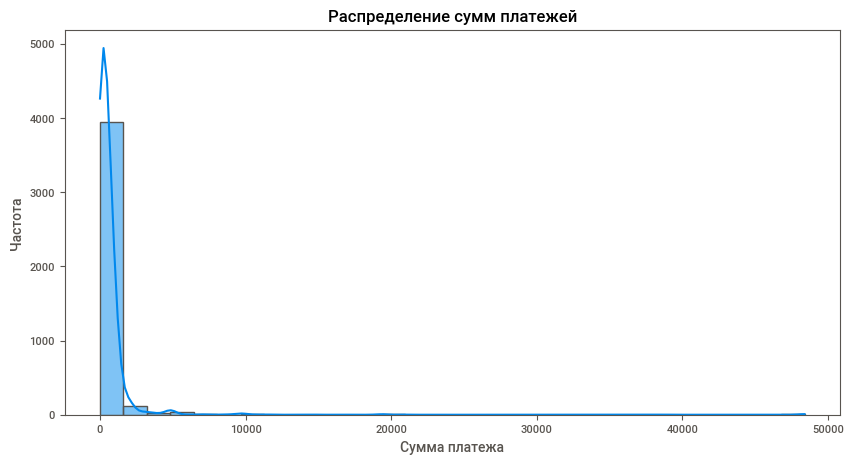

In [27]:
plt.figure(figsize=(10, 5))
sns.histplot(data['Сумма возмещения'], bins=30, kde=True)
plt.title('Распределение сумм платежей')
plt.xlabel('Сумма платежа')
plt.ylabel('Частота')
plt.show()

### Динамика платежей по месяцам <a id="Динамика-платежей-по-месяцам"></a> 

C:\Users\basil\AppData\Local\Temp\ipykernel_6116\1465765482.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  completed_data['Дата и время'] = pd.to_datetime(completed_data['Дата и время'])


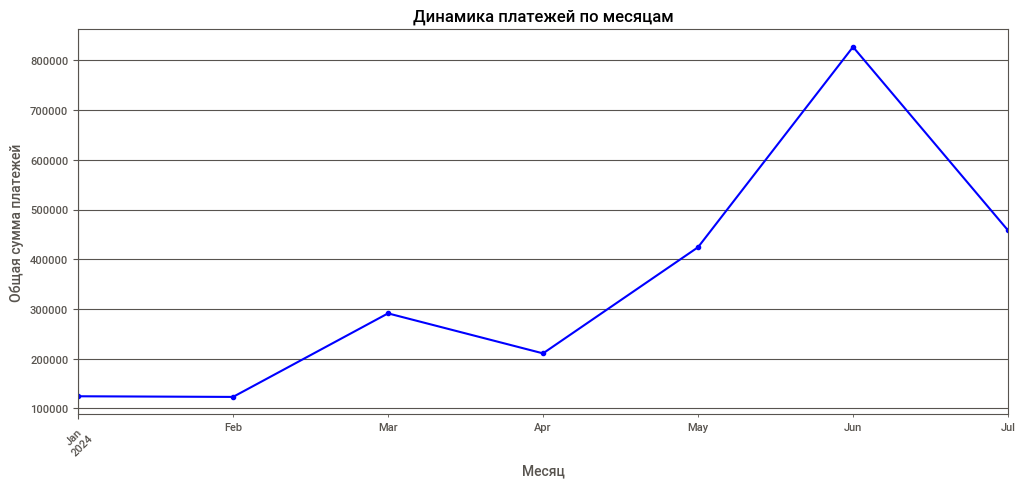

In [28]:
# Преобразуем дату в формат datetime, если нужно
completed_data['Дата и время'] = pd.to_datetime(completed_data['Дата и время'])

# Группируем платежи по месяцам
monthly_payments = completed_data.groupby(data['Дата и время'].dt.to_period("M"))['Сумма возмещения'].sum()

# Строим график динамики платежей
plt.figure(figsize=(12, 5))
monthly_payments.plot(kind='line', marker='o', color='b')
plt.title("Динамика платежей по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Общая сумма платежей")
plt.xticks(rotation=45)
plt.grid()
plt.show()


### ARPU (Средний доход на пользователя), Churn Rate (Отток пользователей), LTV (Lifetime Value) <a id="ARPU-Churn-Rate-LTV"></a> 

C:\Users\basil\AppData\Local\Temp\ipykernel_6116\779164357.py:31: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
C:\Users\basil\AppData\Local\Temp\ipykernel_6116\779164357.py:31: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  plt.tight_layout()
C:\Users\basil\AppData\Local\Temp\ipykernel_6116\779164357.py:31: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from current font.
  plt.tight_layout()
C:\Users\basil\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\basil\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\basil\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing f

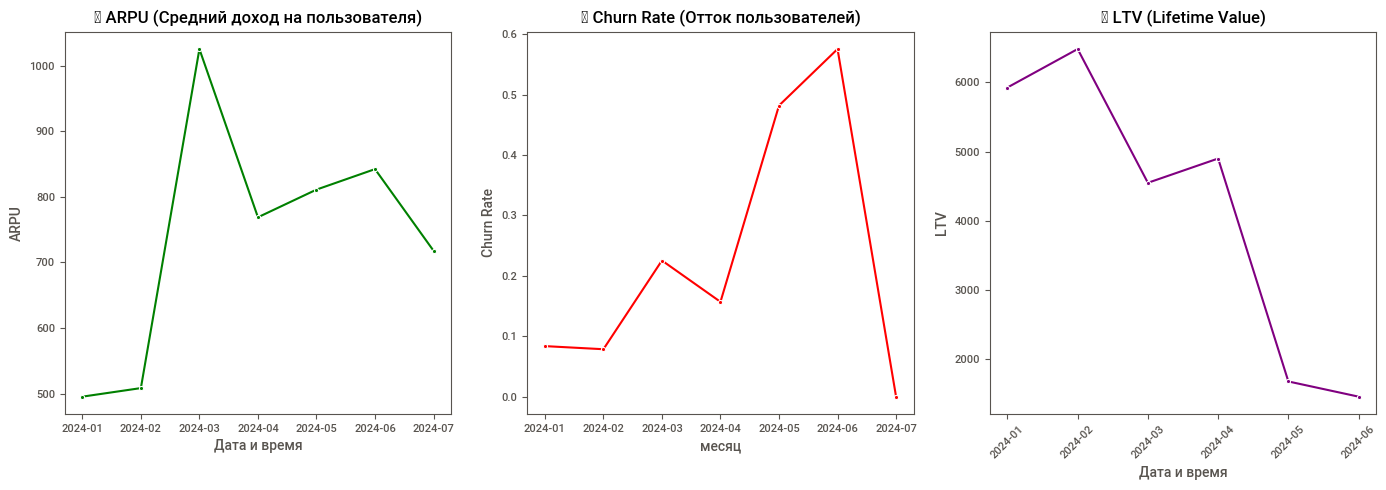

In [29]:

unique_users_per_month = completed_data.groupby("месяц")["Плательщик"].nunique()
# 📌 1. ARPU (Средний доход на пользователя)
arpu_monthly = monthly_payments / unique_users_per_month  # У вас уже есть данные по этим метрикам

# 📌 2. Churn Rate (Отток пользователей)
users_current_month = completed_data.groupby("месяц")["Плательщик"].unique()
users_next_month = users_current_month.shift(-1)  # Сдвигаем пользователей на месяц вперёд

churn_rate = users_current_month.combine(users_next_month, 
                                         lambda curr, next_: len(set(curr) - set(next_)) if next_ is not None else 0) / users_current_month.apply(len)

# 📌 3. LTV (Lifetime Value)
ltv_monthly = arpu_monthly / churn_rate.replace(0, np.nan)  # Делаем деление корректным

# 📌 Визуализация новых метрик
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

sns.lineplot(x=arpu_monthly.index.astype(str), y=arpu_monthly.values, ax=axes[0], marker="o", color="green")
axes[0].set_title("📊 ARPU (Средний доход на пользователя)")
axes[0].set_ylabel("ARPU")

sns.lineplot(x=churn_rate.index.astype(str), y=churn_rate.values, ax=axes[1], marker="o", color="red")
axes[1].set_title("📉 Churn Rate (Отток пользователей)")
axes[1].set_ylabel("Churn Rate")

sns.lineplot(x=ltv_monthly.index.astype(str), y=ltv_monthly.values, ax=axes[2], marker="o", color="purple")
axes[2].set_title("💰 LTV (Lifetime Value)")
axes[2].set_ylabel("LTV")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



## 4. Анализ поведения пользователей <a id="Анализ-поведения-пользователей"></a>  

### Количество уникальных пользователей и их активность <a id="Количество-уникальных-пользователей-и-их-активность"></a> 

In [30]:
# Количество уникальных пользователей
unique_users = data['Плательщик'].nunique()
total_transactions = data.shape[0]

print(f"📌 Всего уникальных пользователей: {unique_users}")
print(f"📊 Всего транзакций: {total_transactions}")

# Группировка по пользователям: сколько раз каждый пользователь совершал платежи
user_activity = data.groupby('Плательщик')['Дата и время'].count().reset_index()
user_activity.columns = ['Плательщик', 'Количество платежей']

# Выводим топ-10 самых активных пользователей
print("🔥 Топ-10 самых активных пользователей:")
print(user_activity.sort_values(by='Количество платежей', ascending=False).head(10))


📌 Всего уникальных пользователей: 1526
📊 Всего транзакций: 4148
🔥 Топ-10 самых активных пользователей:
                    Плательщик  Количество платежей
1219   pollygotl****@gmail.com                   23
1256  rita-muhina****@yadex.ru                   21
1348      st.mar****@gmail.com                   21
929           lial****@list.ru                   21
41     925470602****@gmail.com                   21
579         domo****@gmail.com                   20
1052       morozov****@list.ru                   20
971         marga****@inbox.ru                   20
324            abc****@mail.ru                   19
320          aalpa****@list.ru                   19


### Средний интервал между платежами <a id="Средний-интервал-между-платежами"></a> 

In [31]:
# Преобразуем дату в datetime, если еще не преобразовали
data['Дата и время'] = pd.to_datetime(data['Дата и время'])

# Вычисляем разницу между платежами для каждого пользователя
data = data.sort_values(by=['Плательщик', 'Дата и время'])
data['Интервал между платежами (дни)'] = data.groupby('Плательщик')['Дата и время'].diff().dt.days

# Средний интервал между платежами
mean_interval = data['Интервал между платежами (дни)'].mean()
print(f"📅 Средний интервал между платежами: {mean_interval:.2f} дней")


📅 Средний интервал между платежами: 23.27 дней


### Динамика новых и возвращающихся пользователей <a id="Динамика-новых-и-возвращающихся-пользователей"></a> 

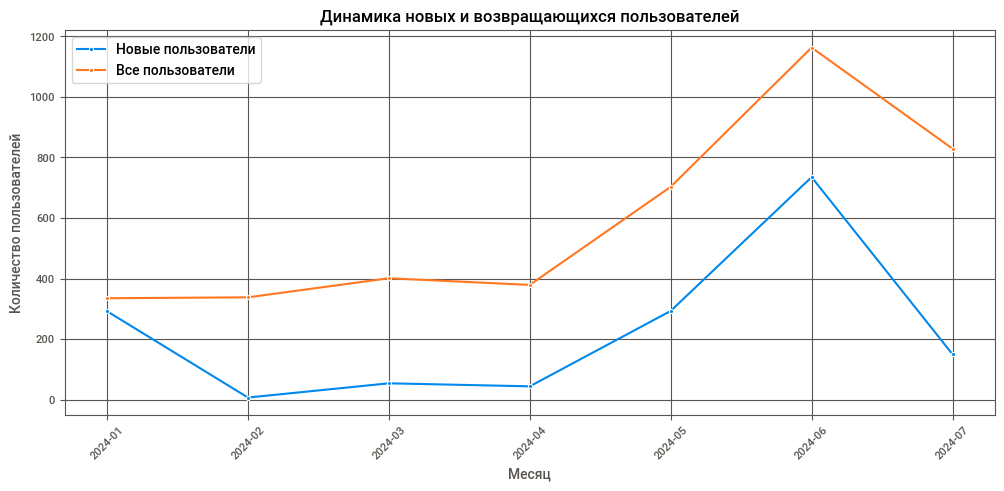

In [32]:
# Определяем первую дату платежа для каждого пользователя
first_purchase = data.groupby('Плательщик')['Дата и время'].min().reset_index()
first_purchase.columns = ['Плательщик', 'Дата первого платежа']

# Добавляем информацию о новом пользователе в основной DataFrame
data = data.merge(first_purchase, on='Плательщик', how='left')

# Определяем, является ли платеж первым в данном месяце
data['Месяц'] = data['Дата и время'].dt.to_period('M')
data['Новый пользователь'] = data['Дата и время'] == data['Дата первого платежа']

# Считаем количество новых и старых пользователей по месяцам
monthly_users = data.groupby('Месяц')['Новый пользователь'].agg(['sum', 'count'])
monthly_users.columns = ['Новые пользователи', 'Всего платежей']

# Визуализация
plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_users, x=monthly_users.index.astype(str), y='Новые пользователи', label='Новые пользователи', marker='o')
sns.lineplot(data=monthly_users, x=monthly_users.index.astype(str), y='Всего платежей', label='Все пользователи', marker='o')
plt.xticks(rotation=45)
plt.xlabel("Месяц")
plt.ylabel("Количество пользователей")
plt.title("Динамика новых и возвращающихся пользователей")
plt.legend()
plt.grid()
plt.show()


## 5. RFM-анализ <a id="RFM-анализ"></a>  

In [33]:
completed_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3327 entries, 0 to 4145
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Номер               3327 non-null   object        
 1   Дата и время        3327 non-null   datetime64[ns]
 2   Тип                 3327 non-null   object        
 3   Сумма возмещения    3327 non-null   float64       
 4   Статус              3327 non-null   object        
 5   месяц               3327 non-null   period[M]     
 6   Плательщик          3327 non-null   object        
 7   Назначение платежа  3327 non-null   object        
 8   дата                3327 non-null   object        
 9   неделя              3327 non-null   period[W-SUN] 
dtypes: datetime64[ns](1), float64(1), object(6), period[M](1), period[W-SUN](1)
memory usage: 415.0+ KB


Поскольку у нас есть 3327 записей и несколько необходимых столбцов, мы будем использовать столбец "Дата и время" для расчета recency, "Сумма возмещения" для monetary, а частоту покупок (frequency) будем рассчитывать на основе уникальных идентификаторов плательщиков.

In [34]:
# Определяем дату анализа
current_date = datetime.now()

# Расчет RFM
rfm = completed_data.groupby('Плательщик').agg({
    'Дата и время': lambda x: (current_date - x.max()).days,  # Recency
    'Номер': 'count',  # Frequency (количество транзакций)
    'Сумма возмещения': 'sum'  # Monetary (сумма покупок)
}).rename(columns={
    'Дата и время': 'Recency',
    'Номер': 'Frequency',
    'Сумма возмещения': 'Monetary'
})

# Выводим RFM
print(rfm.head())

# Проверка уникальных значений
print("Уникальные значения в Recency:")
print(rfm['Recency'].unique())
print("Уникальные значения в Frequency:")
print(rfm['Frequency'].unique())
print("Уникальные значения в Monetary:")
print(rfm['Monetary'].unique())

# Вычисление RFM-баллов (по желанию)
try:
    rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1], duplicates='drop')
except ValueError:
    rfm['R_score'] = pd.cut(rfm['Recency'], bins=4, labels=[4, 3, 2, 1])

try:
    rfm['F_score'] = pd.qcut(rfm['Frequency'], 4, labels=[1, 2, 3, 4], duplicates='drop')
except ValueError:
    rfm['F_score'] = pd.cut(rfm['Frequency'], bins=4, labels=[1, 2, 3, 4])

try:
    rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4], duplicates='drop')
except ValueError:
    rfm['M_score'] = pd.cut(rfm['Monetary'], bins=4, labels=[1, 2, 3, 4])

# Объединение RFM-баллов
rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

# Просмотр RFM-таблицы с баллами
print(rfm[['Recency', 'Frequency', 'Monetary', 'RFM_score']].head())

                Recency  Frequency  Monetary
Плательщик                                  
****@bk.ru          257          1     968.0
****@de.ru          236          1     968.0
****@eml.cc         211          2    1452.0
****@gksnab.ru      294          1    2420.0
****@gmail.com      256          1      96.1
Уникальные значения в Recency:
[257 236 211 294 256 244 254 220 228 227 271 218 249 209 226 258 250 248
 229 213 270 272 277 234 264 356 274 247 238 268 313 336 266 231 225 242
 222 275 245 240 239 269 219 215 237 267 210 282 241 230 276 232 281 233
 263 261 253 359 288 289 212 361 243 259 285 279 216 273 342 246 262 235
 265 334 340 260 221 224 280 320 305 255 322 295 214 316 345 411 406 217
 344 337 223 358 347 314 374 287 284 352 405 398 346 353 360 319 335 330
 291 309 348 394 338 321 252 343 389 296 306 379 251 308 408 377 328 283
 301 412 380 333 357 312 293 400 286 395 362 325]
Уникальные значения в Frequency:
[ 1  2 11 12  7  4  3  5  6 10 14 16 15  8 13  9 20]
Уникаль

**Результаты RFM-анализа предоставляют ценную информацию о поведении клиентов на основе трех ключевых метрик: Recency (давность последней покупки), Frequency (частота покупок) и Monetary (сумма покупок). Вот как можно интерпретировать представленные данные:**

_**Пользовательский профиль:**_

Каждая строка в таблице представляет отдельного клиента (плательщика) и его поведение в системе.
Например, у клиента с электронной почтой `****@bk.ru` Recency составляет 256 дней, что означает, что с момента его последней покупки прошло 256 дней. Это говорит о том, что клиент не взаимодействовал с компанией довольно долго.
Частота покупок:

Клиент `****@bk.ru` совершил всего 1 покупку, что указывает на низкий уровень вовлеченности. Аналогично, клиенты `****@de.ru` и `****@gksnab.ru` также имеют лишь одну покупку за отчетный период.
В отличие от них, клиент `****@eml.cc` сделал 2 покупки, что показывает немного более высокую активность.

_**Сумма покупок:**_

Сумма, потраченная каждым клиентом, варьируется: клиент `****@gksnab.ru` потратил 2420.0 рублей, что является наиболее значительной суммой среди представленных данных, в то время как клиент `****@gmail.com` потратил всего 96.1 рублей.
Высокая сумма покупок у клиента `****@gksnab.ru` может указывать на его важность для бизнеса и потенциальную ценность как клиента.

_**RFM_score:**_

Значение RFM_score объединяет оценки по трем метрикам, и в данном случае оно представлено как трехзначное число.
Например, клиент `****@bk.ru` имеет RFM_score равный 213, что может быть интерпретировано как относительно низкий уровень вовлеченности и ценности, поскольку число 2 в первой позиции указывает на низкую частоту покупок, 1 – на длительный период без активности, и 3 – на среднюю сумму покупок.
Наоборот, клиент `****@eml.cc` с RFM_score 414 имеет более высокий уровень вовлеченности и ценности.

_**Выводы и рекомендации:**_

Необходимо активизировать клиентов с низким RFM_score: Это может включать в себя специальные предложения, скидки или рекламные акции, чтобы вернуть их в активное состояние и увеличить их частоту покупок.
Углубленное внимание к высокоценным клиентам: Клиенты, такие как `****@gksnab.ru`, должны быть приоритетом для компании, и им следует предлагать программы лояльности или персонализированные предложения, чтобы удерживать их и побуждать к дальнейшим покупкам.

Анализ причин низкой активности: Следует проанализировать, почему клиенты, такие как `****@bk.ru` и `****@de.ru`, не совершали покупки в течение длительного времени, возможно, это связано с недостатком интереса к продуктам или услугам, а также с возможными проблемами в обслуживании.

Эти выводы помогут в разработке стратегии маркетинга и продаж, направленной на улучшение вовлеченности клиентов и увеличение прибыли.

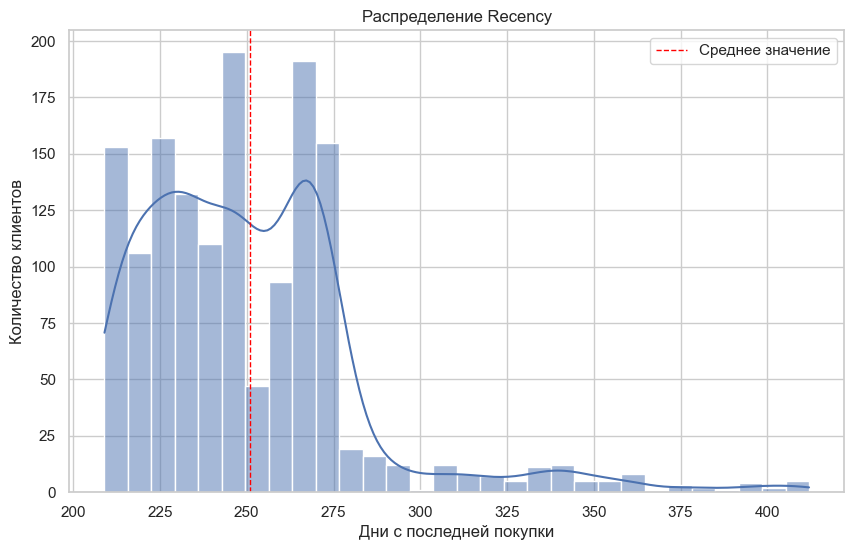

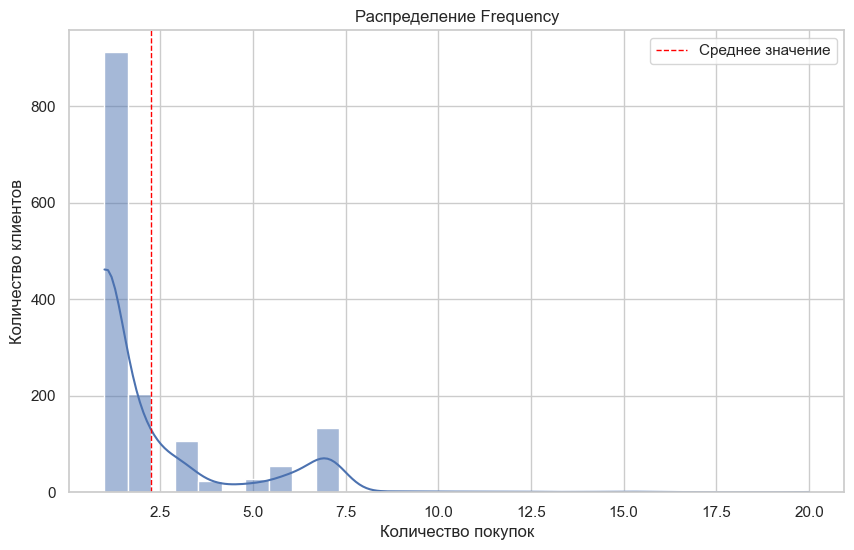

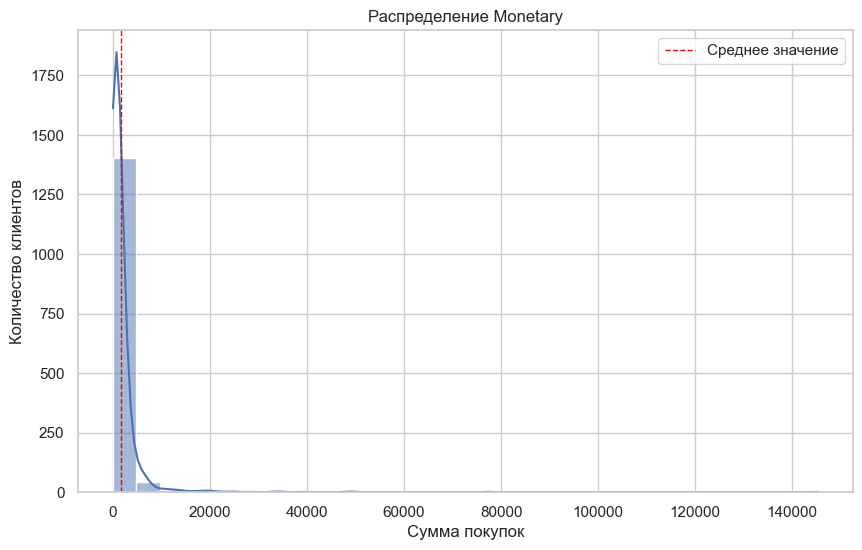

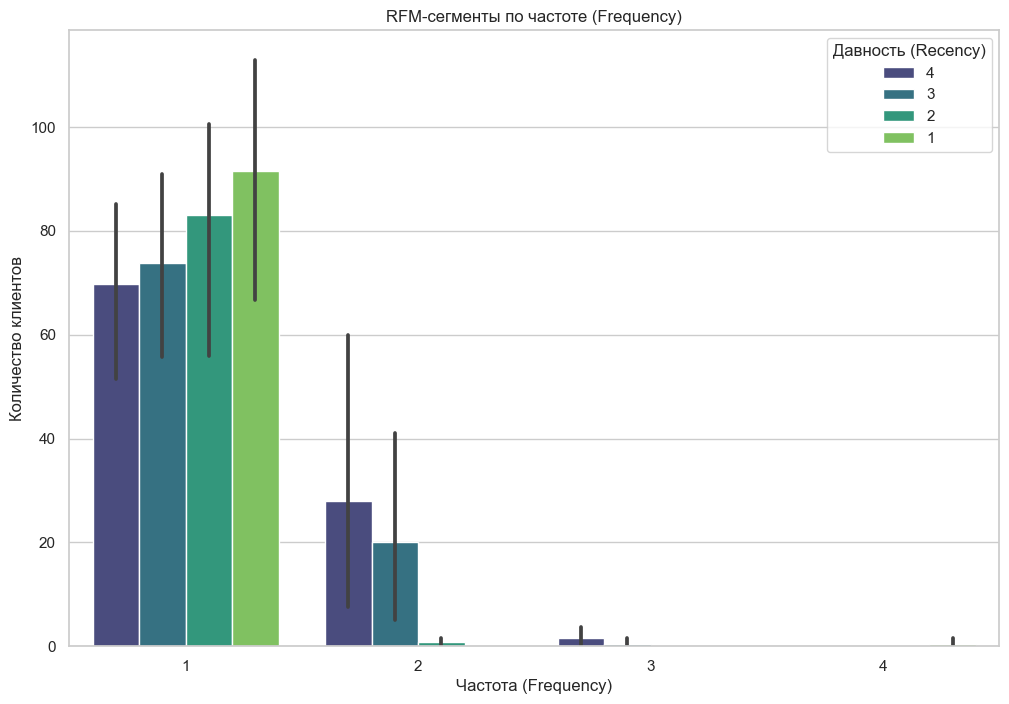

In [35]:
sns.set(style="whitegrid")

# Визуализация Recency
plt.figure(figsize=(10, 6))
sns.histplot(rfm['Recency'], bins=30, kde=True)
plt.title('Распределение Recency')
plt.xlabel('Дни с последней покупки')
plt.ylabel('Количество клиентов')
plt.axvline(rfm['Recency'].mean(), color='red', linestyle='dashed', linewidth=1, label='Среднее значение')
plt.legend()
plt.show()

# Визуализация Frequency
plt.figure(figsize=(10, 6))
sns.histplot(rfm['Frequency'], bins=30, kde=True)
plt.title('Распределение Frequency')
plt.xlabel('Количество покупок')
plt.ylabel('Количество клиентов')
plt.axvline(rfm['Frequency'].mean(), color='red', linestyle='dashed', linewidth=1, label='Среднее значение')
plt.legend()
plt.show()

# Визуализация Monetary
plt.figure(figsize=(10, 6))
sns.histplot(rfm['Monetary'], bins=30, kde=True)
plt.title('Распределение Monetary')
plt.xlabel('Сумма покупок')
plt.ylabel('Количество клиентов')
plt.axvline(rfm['Monetary'].mean(), color='red', linestyle='dashed', linewidth=1, label='Среднее значение')
plt.legend()
plt.show()

# Визуализация RFM-сегментов
plt.figure(figsize=(12, 8))
rfm_grouped = rfm.groupby(['R_score', 'F_score', 'M_score']).size().reset_index(name='Count')
sns.barplot(data=rfm_grouped, x='F_score', y='Count', hue='R_score', palette='viridis')
plt.title('RFM-сегменты по частоте (Frequency)')
plt.xlabel('Частота (Frequency)')
plt.ylabel('Количество клиентов')
plt.legend(title='Давность (Recency)')
plt.show()

In [36]:
# Сегментация клиентов на основе RFM
def segment_clients(row):
    if row['Frequency'] > 1 and row['Monetary'] > 1000:
        return 'Лояльные клиенты'
    elif row['Frequency'] == 1 and row['Monetary'] > 1000:
        return 'Редкие покупатели'
    else:
        return 'Потенциальные клиенты'

rfm['Segment'] = rfm.apply(segment_clients, axis=1)

# Индикаторы активности
# Коэффициент удержания клиентов

retained_customers = completed_data[completed_data['Дата и время'] >= (datetime.now() - pd.DateOffset(months=7))]
retention_rate = retained_customers['Плательщик'].nunique() / rfm.index.nunique()

# Средняя стоимость заказа
average_order_value = rfm['Monetary'].sum() / rfm['Frequency'].sum()

# Динамика RFM-метрик

rfm['Date'] = datetime.now().date()


# Просмотр результатов
print(rfm[['Recency', 'Frequency', 'Monetary', 'Segment']].head())
print(f'Коэффициент удержания клиентов: {retention_rate:.2%}')
print(f'Средняя стоимость заказа: {average_order_value:.2f}')

                Recency  Frequency  Monetary                Segment
Плательщик                                                         
****@bk.ru          257          1     968.0  Потенциальные клиенты
****@de.ru          236          1     968.0  Потенциальные клиенты
****@eml.cc         211          2    1452.0       Лояльные клиенты
****@gksnab.ru      294          1    2420.0      Редкие покупатели
****@gmail.com      256          1      96.1  Потенциальные клиенты
Коэффициент удержания клиентов: 9.75%
Средняя стоимость заказа: 738.93


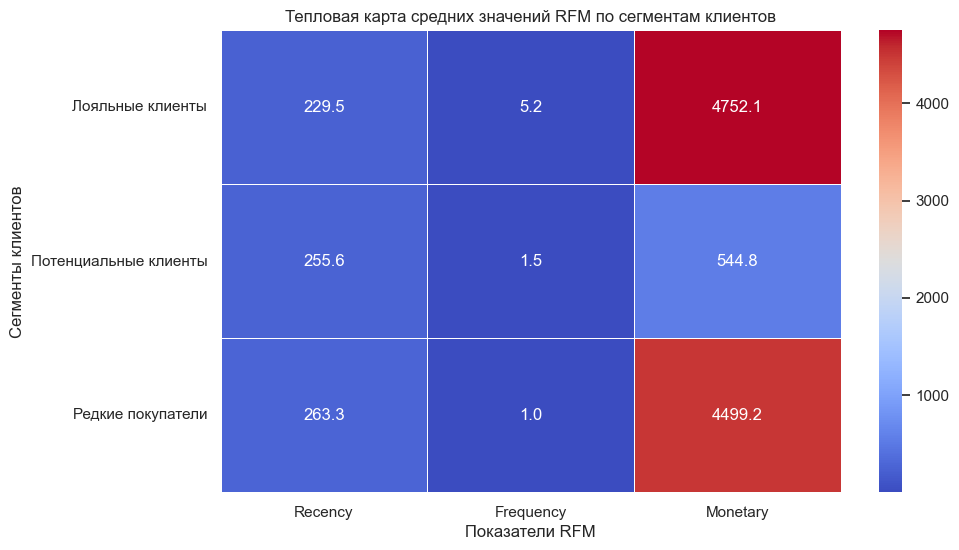

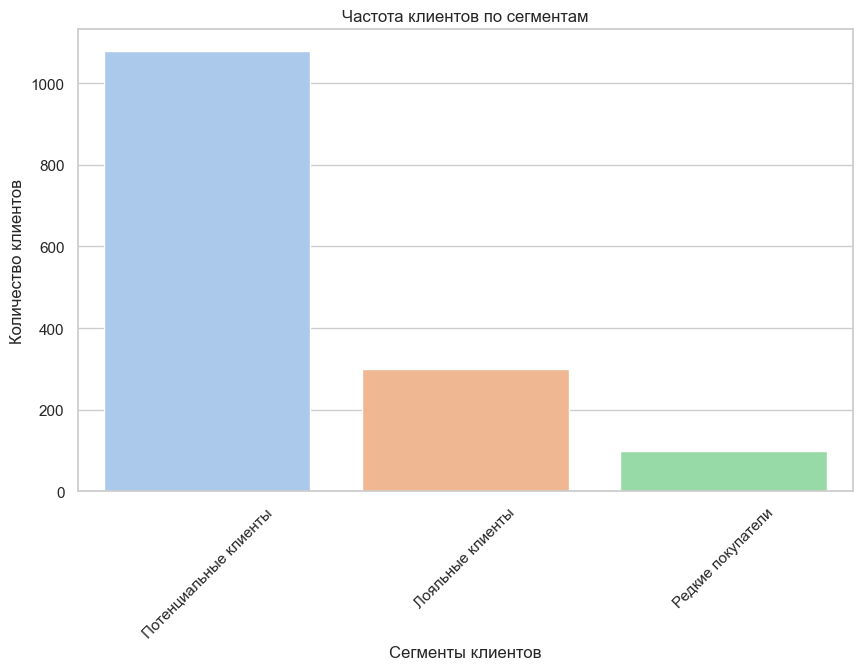

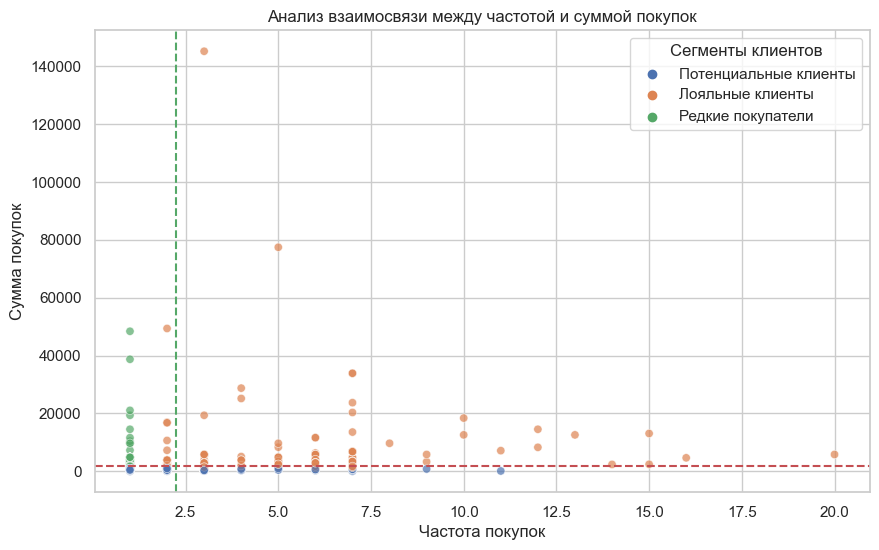

In [37]:
# Убедитесь, что числовые столбцы правильно указаны
rfm_numeric = rfm[['Recency', 'Frequency', 'Monetary', 'Segment']].copy()
rfm_numeric['Segment'] = rfm_numeric['Segment'].astype('category')

# Тепловая карта RFM-средних значений по сегментам
rfm_grouped = rfm_numeric.groupby('Segment').mean()[['Recency', 'Frequency', 'Monetary']]
plt.figure(figsize=(10, 6))
sns.heatmap(rfm_grouped, annot=True, fmt=".1f", cmap='coolwarm', linewidths=.5)
plt.title('Тепловая карта средних значений RFM по сегментам клиентов')
plt.xlabel('Показатели RFM')
plt.ylabel('Сегменты клиентов')
plt.show()

# Гистограмма для частоты клиентов по сегментам
plt.figure(figsize=(10, 6))
sns.countplot(data=rfm, x='Segment', order=rfm['Segment'].value_counts().index, palette='pastel')
plt.title('Частота клиентов по сегментам')
plt.xlabel('Сегменты клиентов')
plt.ylabel('Количество клиентов')
plt.xticks(rotation=45)
plt.show()

# График разброса для анализа взаимосвязи между частотой и суммой покупок
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Segment', palette='deep', alpha=0.7)
plt.title('Анализ взаимосвязи между частотой и суммой покупок')
plt.xlabel('Частота покупок')
plt.ylabel('Сумма покупок')
plt.axhline(y=rfm['Monetary'].mean(), color='r', linestyle='--')  # Линия среднего значения
plt.axvline(x=rfm['Frequency'].mean(), color='g', linestyle='--')  # Линия среднего значения
plt.legend(title='Сегменты клиентов')
plt.show()

## 6. Когортный анализ <a id="Когортный-анализ"></a>  

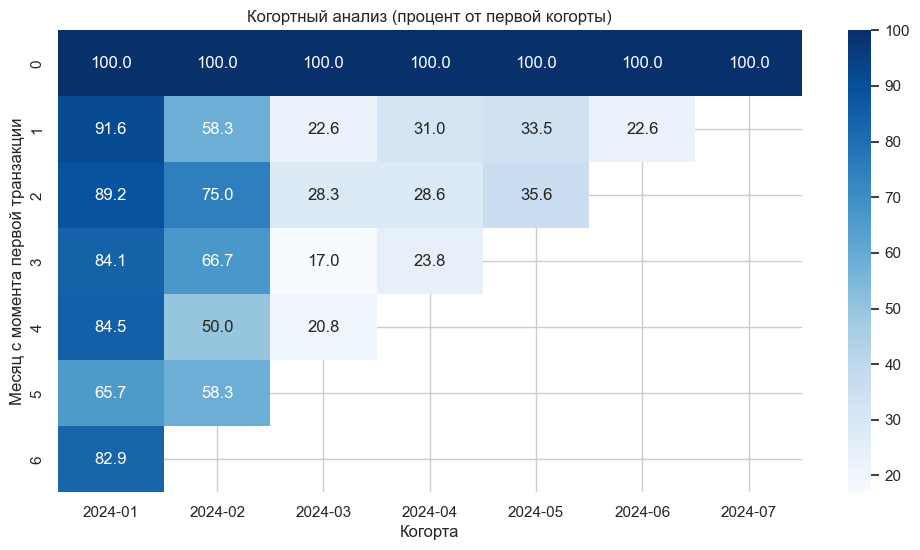

cohort_group,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07
cohort_index,,,,,,,
0,251.0,12.0,53.0,42.0,275.0,698.0,146.0
1,230.0,7.0,12.0,13.0,92.0,158.0,NaN
2,224.0,9.0,15.0,12.0,98.0,NaN,NaN
3,211.0,8.0,9.0,10.0,NaN,NaN,NaN
4,212.0,6.0,11.0,NaN,NaN,NaN,NaN
5,165.0,7.0,NaN,NaN,NaN,NaN,NaN
6,208.0,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
df = completed_data.copy()

def cohort_analysis(df):
    # Преобразуем дату в формат года и месяца
    df['cohort_month'] = df['Дата и время'].dt.to_period('M')
    
    # Определяем первый месяц для каждого плательщика
    df['cohort_group'] = df.groupby('Плательщик')['cohort_month'].transform('min')
    
    # Рассчитываем номер когорты (разница между текущим и стартовым месяцем)
    df['cohort_index'] = (df['cohort_month'] - df['cohort_group']).apply(lambda x: x.n)
    
    # Формируем когортную таблицу
    cohort_data = df.groupby(['cohort_group', 'cohort_index'])['Плательщик'].nunique().unstack(0)
    
    # Нормализуем данные (конверсия в процентах от первой когорты)
    cohort_percentage = cohort_data.divide(cohort_data.iloc[0], axis=1) * 100
    
    # Визуализация когортного анализа
    plt.figure(figsize=(12, 6))
    sns.heatmap(cohort_percentage, annot=True, fmt='.1f', cmap='Blues')
    plt.title('Когортный анализ (процент от первой когорты)')
    plt.ylabel('Месяц с момента первой транзакции')
    plt.xlabel('Когорта')
    plt.show()
    
    return cohort_data


cohort_analysis(df)


# 📊 Результаты когортного анализа  

## **Общий принцип**  
Когорты формируются по месяцу первой транзакции пользователей. В таблице каждая строка — это когорта, а каждый столбец показывает, сколько пользователей из этой когорты совершили транзакции в последующие месяцы.  

## **Разбор результатов:**  
### **Когорта 0 (январь 2024)**
- В январе было **251** уникальных пользователей.  
- В феврале из них осталось **12** (значительное снижение).  
- В марте их количество выросло до **53**, в апреле — **42**.  
- В мае активность этой когорты резко возросла до **275**, в июне — до **698**.  
- В июле число активных пользователей из этой когорты снизилось до **146**.  
- Такое поведение может говорить о **сезонности или маркетинговых кампаниях**, стимулирующих возврат пользователей в мае-июне.  

### **Когорта 1 (февраль 2024)**
- В феврале зарегистрировалось **230** пользователей.  
- В марте их осталось **7**, в апреле — **12**, в мае — **13**.  
- В июне активность увеличилась до **92**, в июле — до **158**.  
- Вероятно, часть пользователей **возвращается через некоторое время**.  

### **Когорта 2 (март 2024)**
- В марте пришло **224** пользователей.  
- В апреле осталось **9**, в мае — **15**, в июне — **12**.  
- В июле пользователи этой когорты не вернулись (**NaN**).  

### **Когорта 3 (апрель 2024)**
- В апреле стартовало **211** пользователей.  
- В мае осталось **8**, в июне — **9**, в июле — **10**.  
- У этой когорты наблюдается **постепенное снижение без всплесков активности**.  

### **Когорта 4 (май 2024)**
- В мае пришло **212** пользователей.  
- В июне их осталось **6**, в июле — **11**.  
- Количество пользователей **продолжает снижаться**.  

### **Когорта 5 (июнь 2024)**
- В июне зарегистрировались **165** пользователей.  
- В июле осталось **7**.  

### **Когорта 6 (июль 2024)**
- В июле пришло **208** пользователей, но данных по следующим месяцам пока нет.  

---

## **Выводы:**
1. **Резкий спад в первые месяцы**  
   - Во всех когортах значительная часть пользователей **перестает быть активной уже через месяц** после первой транзакции. Это говорит о высоком оттоке новых клиентов.  

2. **Рост активности в мае-июне**  
   - Когорта января показала **всплеск активности** в мае и июне (275 и 698 пользователей).  
   - Это может быть связано с **сезонностью или маркетинговыми акциями**.  

3. **Когорта февраля показывает задержанный рост**  
   - В первый месяц после старта активность падала, но в июне и июле количество пользователей резко увеличилось (**92 и 158**).  
   - Возможно, пользователи **вернулись после длительного периода неактивности**.  

4. **Новые когорты (июнь-июль) пока без данных**  
   - Данные за июль показывают только **начальное количество пользователей**, но еще нет информации о том, сколько останется активными в следующие месяцы.  

---

## **Рекомендации**  
- 📉 **Анализировать причины оттока в первый месяц**  
  - Возможно, пользователям **не хватает мотивации** или удобства в использовании сервиса.  
- 🔍 **Исследовать причины роста активности в мае-июне**  
  - Это может быть **результатом рекламных кампаний или сезонного спроса**.  
- 🎯 **Создать стратегию удержания пользователей**  
  - Например, **стимулировать повторные транзакции** через персонализированные предложения.  


In [39]:
!jupytext --to py "Простые вещи.ipynb"

[jupytext] Reading Простые вещи.ipynb in format ipynb
[jupytext] Writing 'Простые вещи.py'
